In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df=pd.read_csv('/content/drive/MyDrive/Clean_Dataset.csv')

In [5]:
df.head(4)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955


In [6]:
df.shape

(300153, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [8]:
df=df.drop(['Unnamed: 0','flight'],axis=1)

In [9]:
df.duplicated().sum()

np.int64(2213)

In [10]:
df=df.drop_duplicates()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297940 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           297940 non-null  object 
 1   source_city       297940 non-null  object 
 2   departure_time    297940 non-null  object 
 3   stops             297940 non-null  object 
 4   arrival_time      297940 non-null  object 
 5   destination_city  297940 non-null  object 
 6   class             297940 non-null  object 
 7   duration          297940 non-null  float64
 8   days_left         297940 non-null  int64  
 9   price             297940 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 25.0+ MB


In [12]:
df.describe()

,duration,days_left,price
count,297940.000000,297940.000000,297940.000000
mean,12.283063,26.004602,20976.448604
std,7.176754,13.557190,22734.394635
min,0.830000,1.000000,1105.000000
25%,6.920000,15.000000,4792.000000
50%,11.330000,26.000000,7466.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [13]:
(df['price'] < 0).sum()

np.int64(0)

In [14]:
df['price'].sort_values(ascending=False).head(5)

,price
261377,123071
216096,117307
215859,116562
277345,115211
270999,114705


In [15]:
df[df['price'] > 200000].sum()

,0
airline,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0.0
days_left,0
price,0


In [16]:
df['price'].skew()

np.float64(1.0539489226197707)

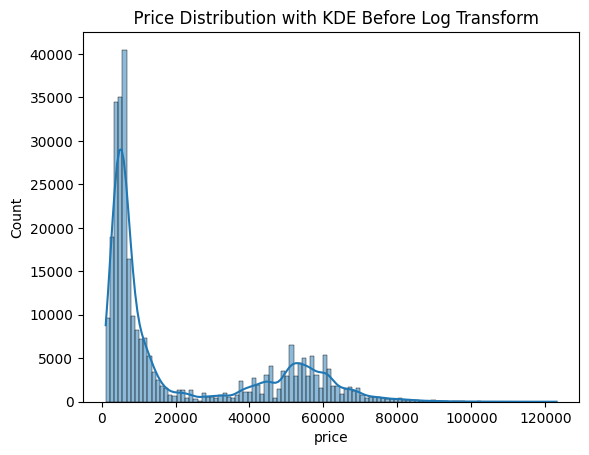

In [17]:
sns.histplot(df['price'], kde=True)
plt.title("  Price Distribution with KDE Before Log Transform")
plt.show()

In [18]:
df['price'] = np.log1p(df['price'])

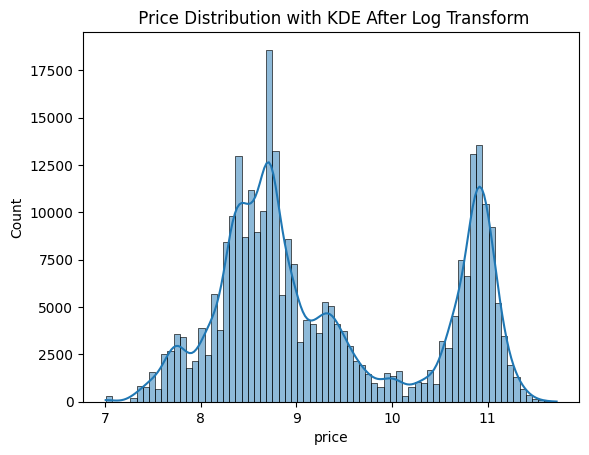

In [19]:
sns.histplot(df['price'], kde=True)
plt.title(" Price Distribution with KDE After Log Transform")
plt.show()

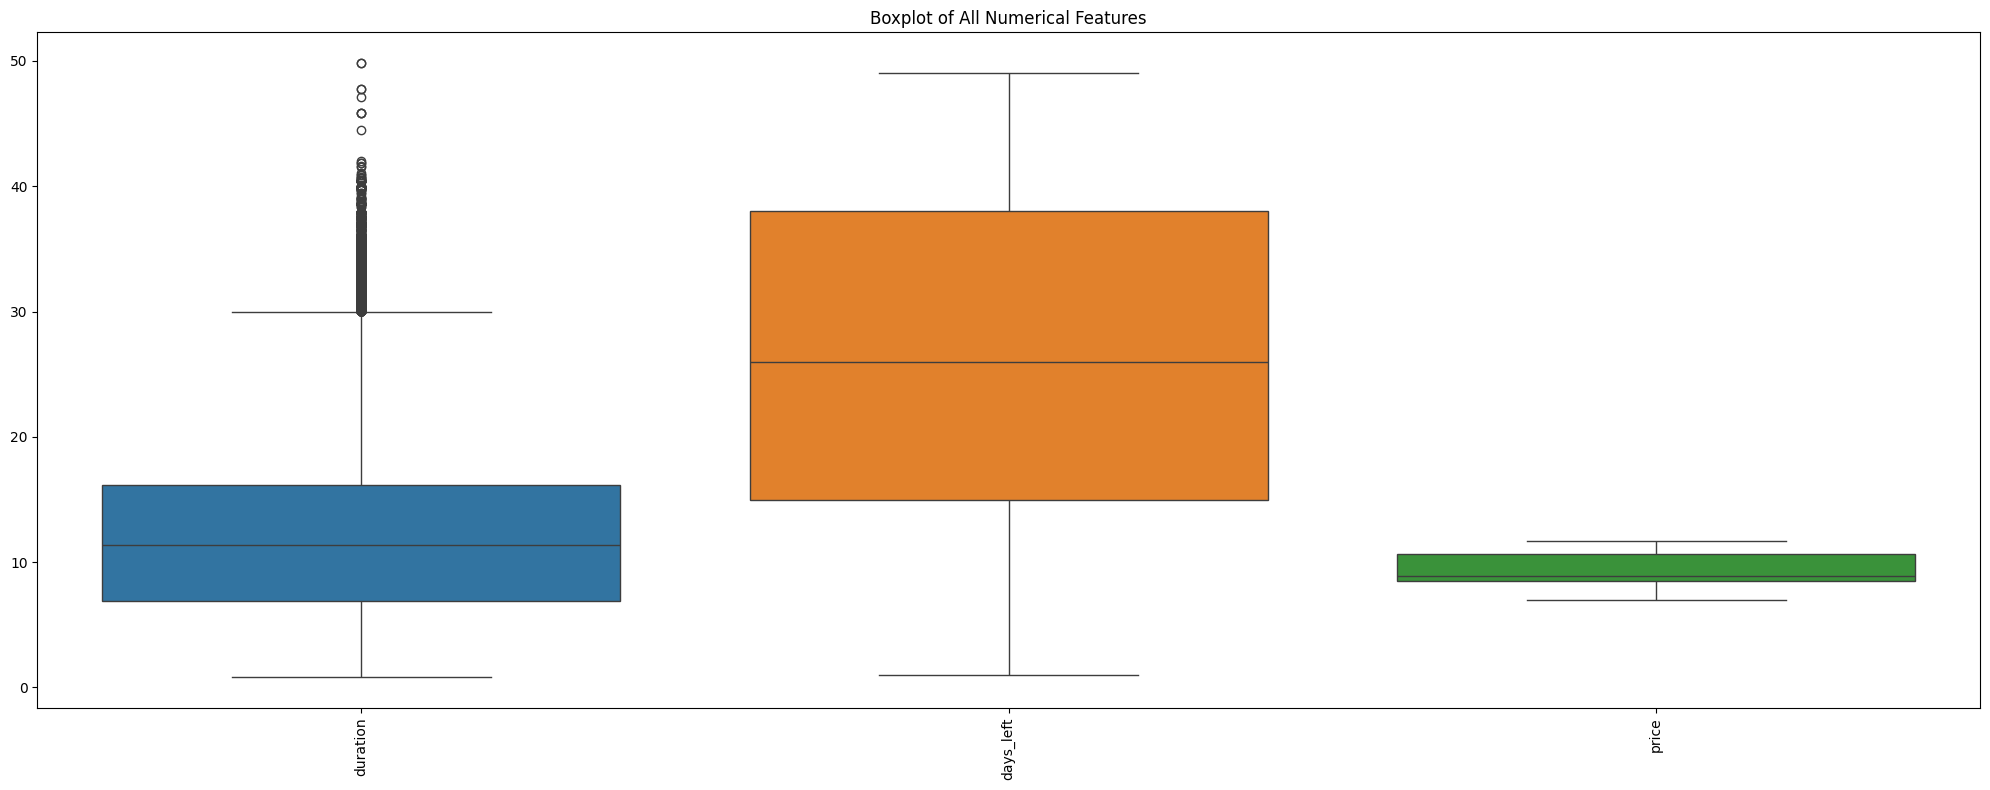

In [20]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.tight_layout()
plt.show()

In [21]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print("Number of Outliers:",len(outliers))

Number of Outliers: 0


In [22]:
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers1 = df[(df['duration'] < lower) | (df['duration'] > upper)]

print("Number of Outliers:",len(outliers1))

Number of Outliers: 2226


In [23]:
pip install feature_engine

In [24]:
from feature_engine.outliers import Winsorizer
winsor=Winsorizer(capping_method="iqr",tail="both",fold = 1.5)
df['duration']=winsor.fit_transform(df[['duration']])

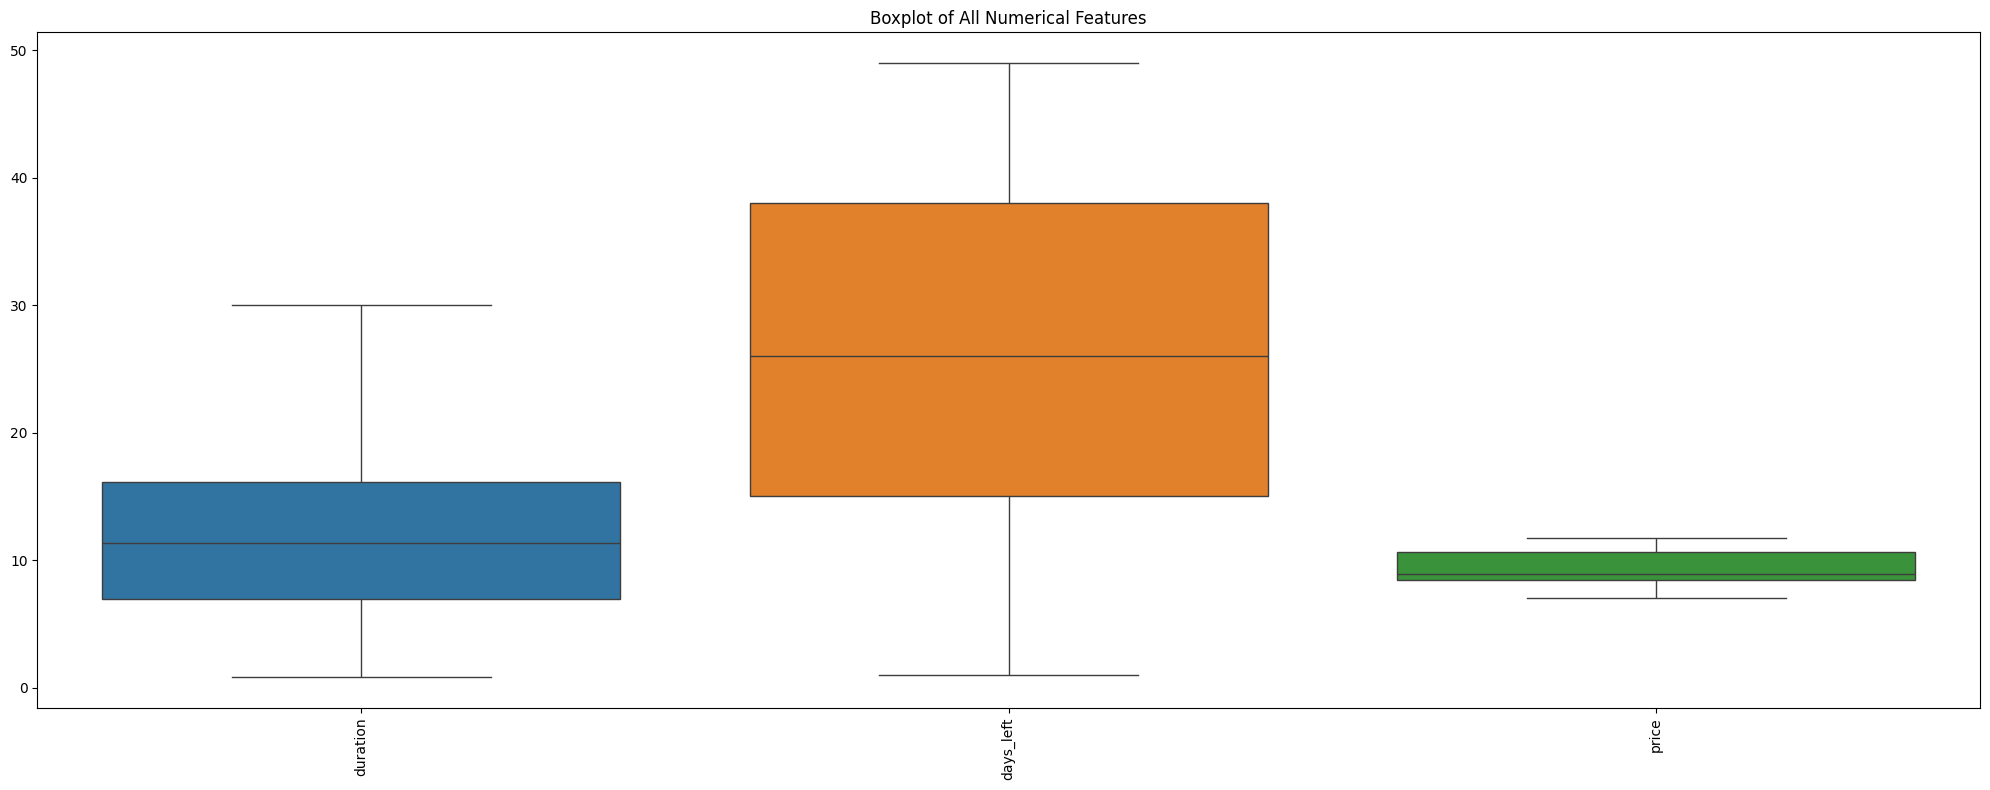

In [25]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of All Numerical Features")
plt.tight_layout()
plt.show()

In [26]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['duration', 'days_left', 'price'], dtype='object')


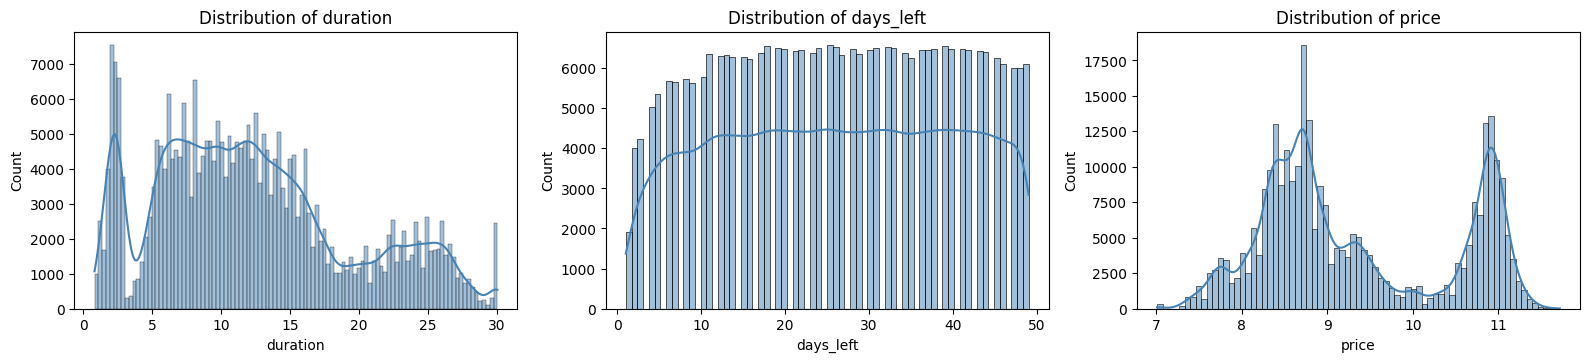

In [27]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(16,10))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True,color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

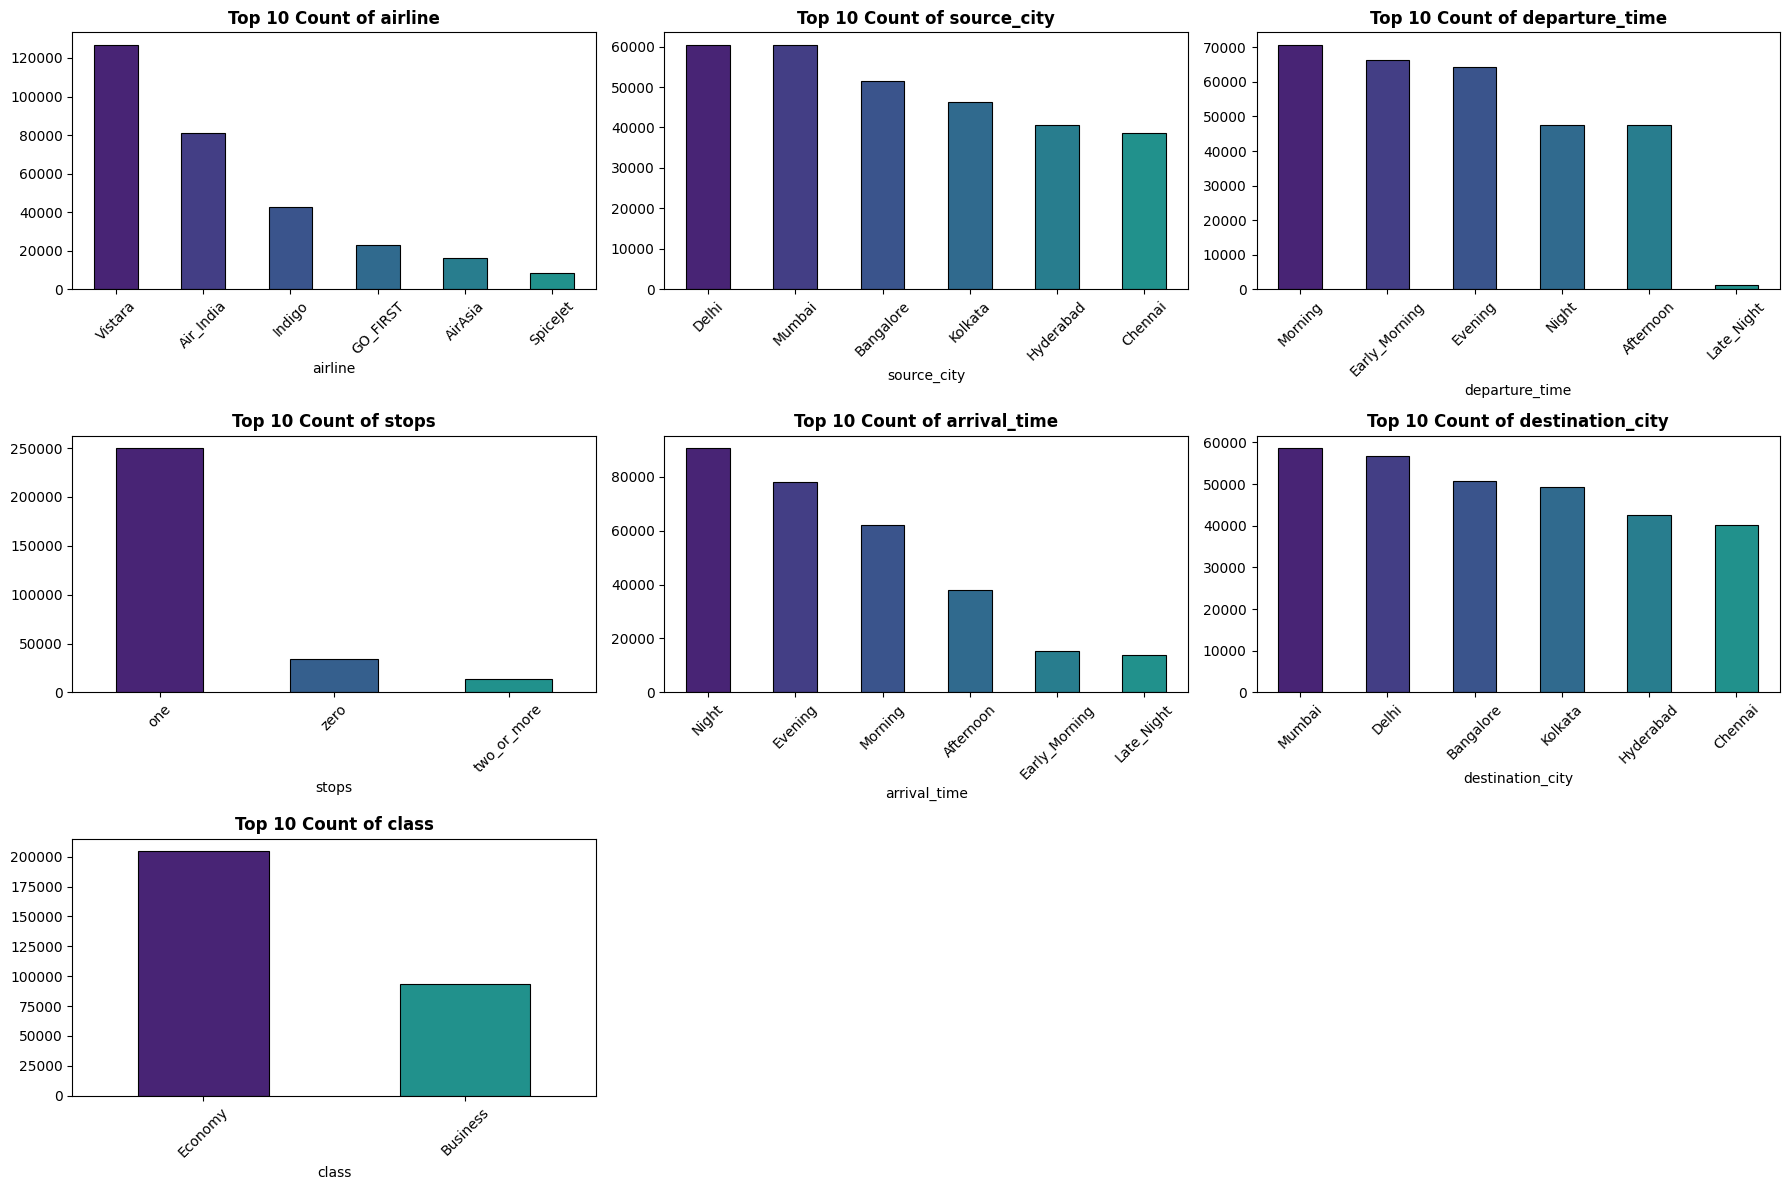

In [28]:
cat_cols=['airline','source_city','departure_time','stops',
          'arrival_time','destination_city','class']
plt.figure(figsize=(18,12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3,3,i)
    data = df[col].value_counts().head(10)
    cmap = plt.colormaps['viridis']
    colors = cmap(np.linspace(0.1, 0.5, len(data)))
    data.plot(kind='bar',color=colors,edgecolor='black',linewidth=0.8)
    plt.title(f'Top 10 Count of {col}', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

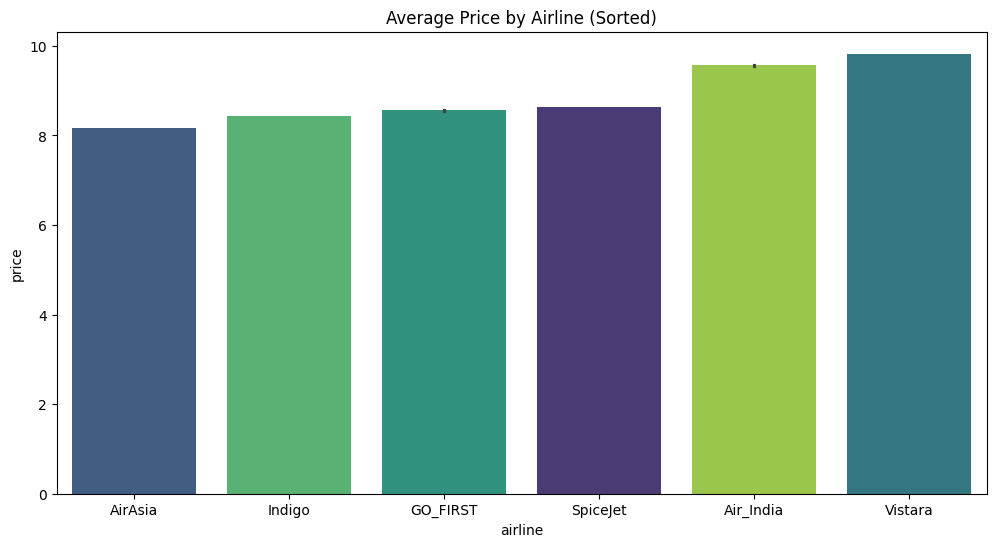

In [29]:
plt.figure(figsize=(12, 6))
order = df.groupby('airline')['price'].mean().sort_values().index

sns.barplot(x='airline',y='price',data=df,order=order,palette='viridis',
    hue='airline',
    legend=False)
plt.title('Average Price by Airline (Sorted)')
plt.show()

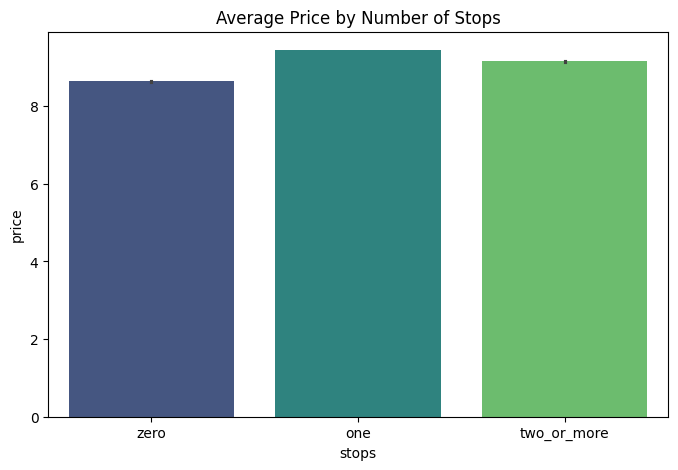

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(x='stops',y='price',data=df,
    order=['zero', 'one', 'two_or_more'],
    palette='viridis',
    hue='stops',
    legend=False)
plt.title("Average Price by Number of Stops")
plt.show()

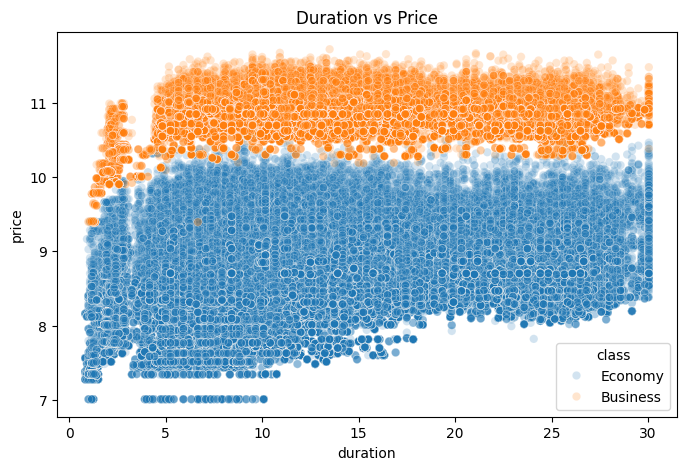

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='duration', y='price', hue='class', data=df, alpha=0.2)
plt.title("Duration vs Price")
plt.show()

Text(0.5, 1.0, 'Average Flight Price vs Days Left Before Departure')

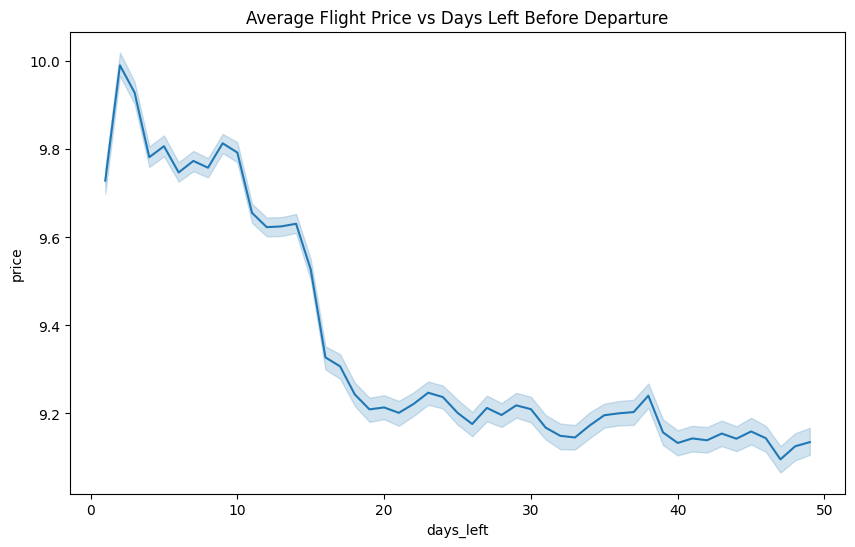

In [32]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='days_left', y='price')
plt.title('Average Flight Price vs Days Left Before Departure')

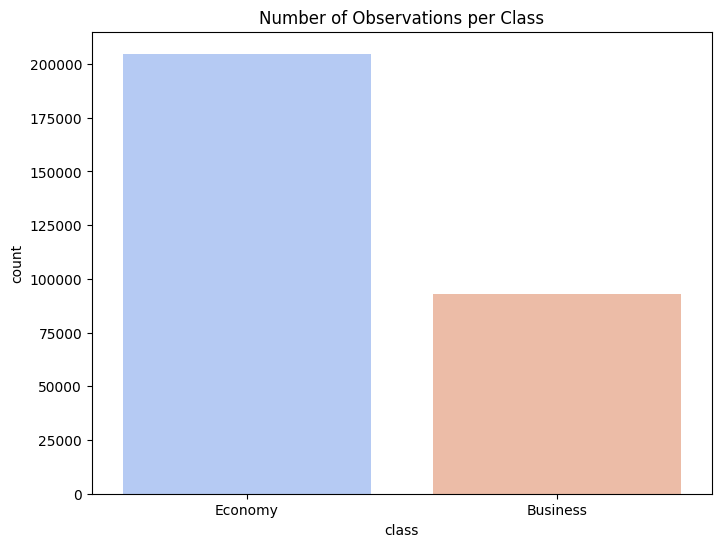

In [33]:
plt.figure(figsize=(8,6))
sns.countplot(x='class', data=df, palette='coolwarm')
plt.title("Number of Observations per Class")
plt.show()

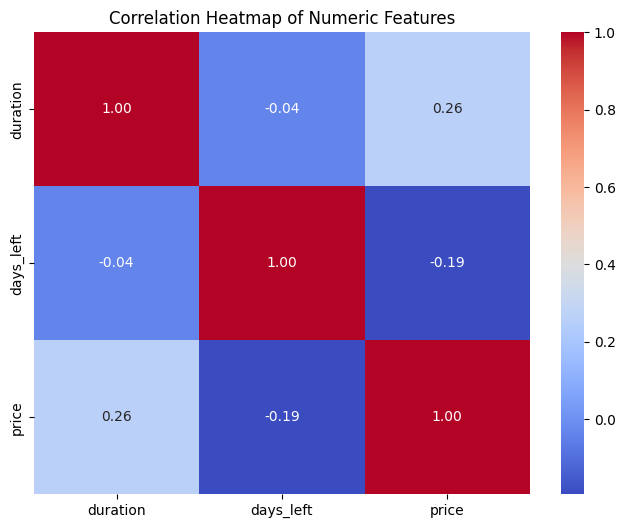

In [34]:
num_cols = ['duration', 'days_left', 'price']
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

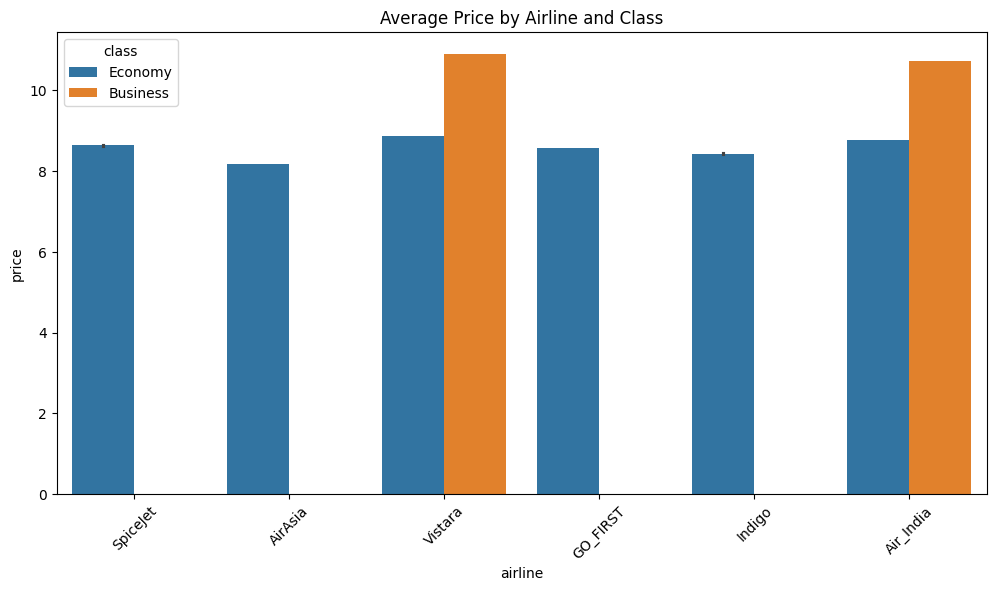

In [35]:
plt.figure(figsize=(12,6))
sns.barplot(data=df,x='airline',y='price',hue='class',estimator='mean')
plt.xticks(rotation=45)
plt.title("Average Price by Airline and Class")
plt.show()

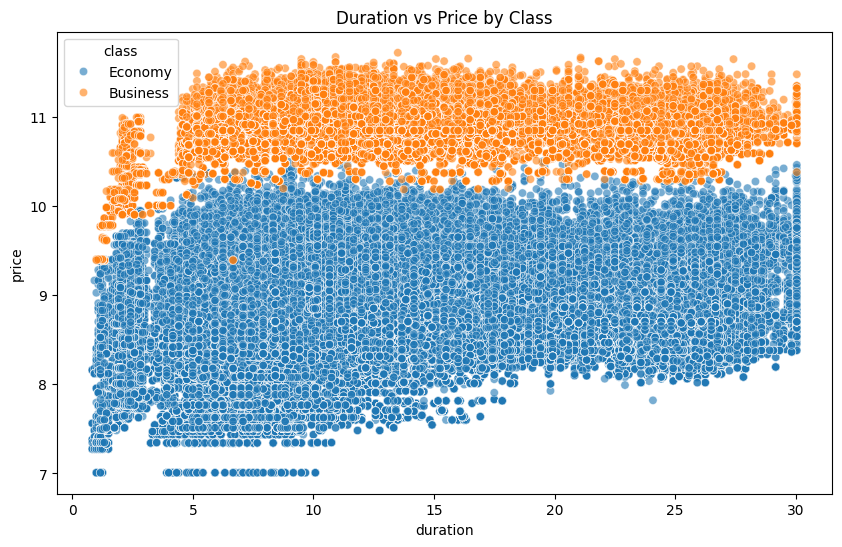

In [36]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='duration',y='price',hue='class',data=df,alpha=0.6)
plt.title("Duration vs Price by Class")
plt.show()

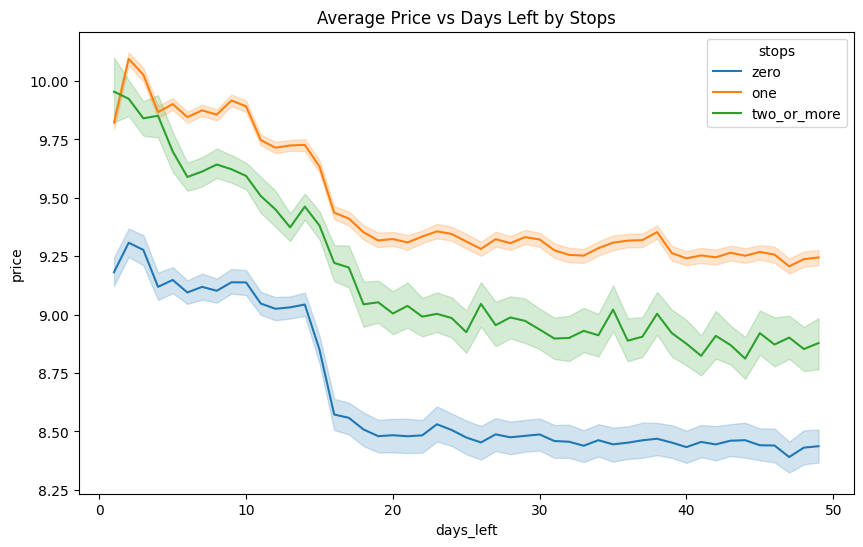

In [37]:
plt.figure(figsize=(10,6))
sns.lineplot(x='days_left',y='price',hue='stops',data=df,estimator='mean')
plt.title("Average Price vs Days Left by Stops")
plt.show()

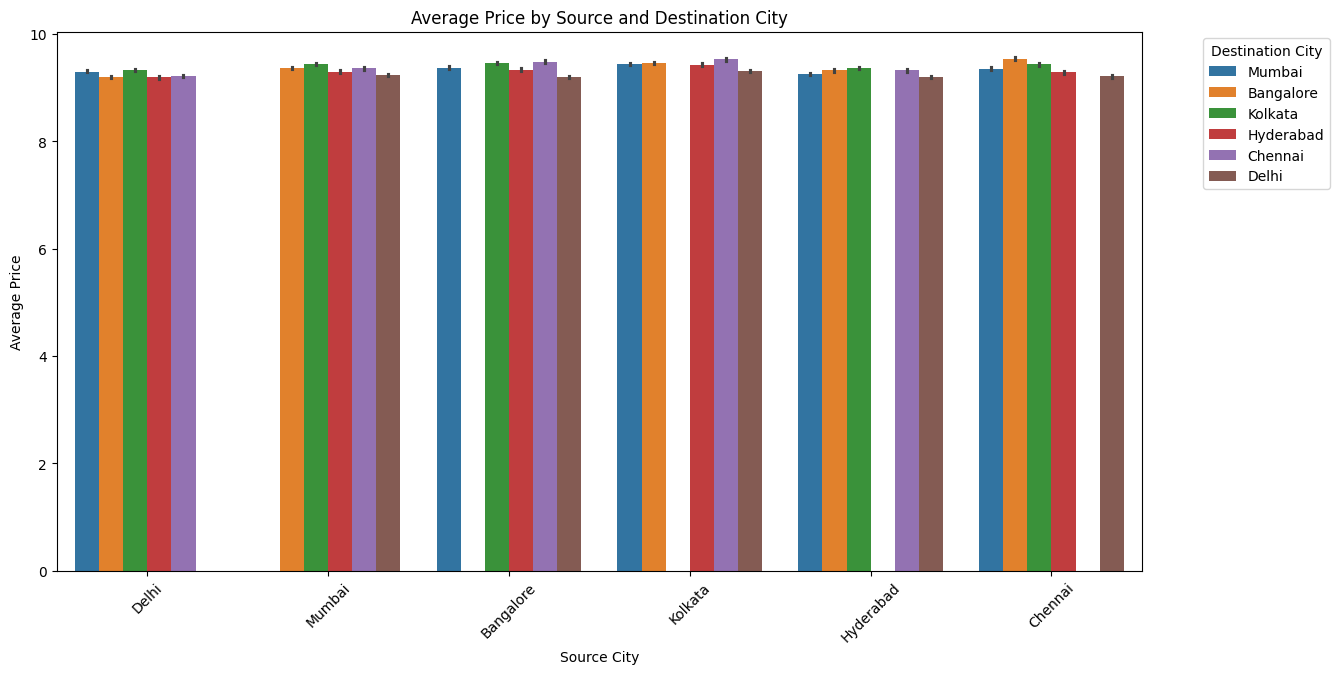

In [38]:
plt.figure(figsize=(14,7))
sns.barplot(data=df,x='source_city',y='price',hue='destination_city',estimator='mean',dodge=True)
plt.title("Average Price by Source and Destination City")
plt.xticks(rotation=45)
plt.xlabel("Source City")
plt.ylabel("Average Price")
plt.legend(title="Destination City", bbox_to_anchor=(1.05,1))
plt.show()

In [39]:
X = df.drop('price', axis=1)
y = df['price']

In [40]:
num_cols=X.select_dtypes(include=['int64','float64']).columns
print(num_cols)
cat_cols=X.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['duration', 'days_left'], dtype='object')
Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class'],
      dtype='object')


In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)])


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(238352, 9)
(59588, 9)
(238352,)
(59588,)


In [43]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10,random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50,max_depth=10,random_state=42,n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=50,max_depth=10,random_state=42),
    "XGB": XGBRegressor(n_estimators=50,max_depth=6,learning_rate=0.1,n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(n_estimators=50,random_state=42)
}


In [44]:
param_grids = {

    'Linear Regression': {
        'regressor__fit_intercept': [True, False]
    },

    'Decision Tree': {
        'regressor__max_depth': [5, 10, 15],
        'regressor__min_samples_split': [5, 10]
    },

    'Random Forest': {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [10, 15, 20],
        'regressor__min_samples_split': [5, 10],
        'regressor__min_samples_leaf': [2, 5]
    },

    'Gradient Boosting': {
        'regressor__n_estimators': [50, 100],
        'regressor__learning_rate': [0.05, 0.1]
    },

    'AdaBoost': {
        'regressor__n_estimators': [50, 100],
        'regressor__learning_rate': [0.01, 0.1]
    },

    'KNN': {
        'regressor__n_neighbors': [3, 5, 7]
    },

    'XGB': {
        'regressor__n_estimators': [50, 100],
        'regressor__learning_rate': [0.05, 0.1],
        'regressor__max_depth': [3, 5]
    }

}

In [45]:
results = []
best_models = {}

for name, model in models.items():
    print(f"Processing Model: {name}")

    # . Define the Single Pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # BEFORE TUNING (Baseline)
    pipe.fit(X_train, y_train)
    y_pred_base = pipe.predict(X_test)

    # FIXED: Inverse transform
    y_pred_base_actual = np.expm1(y_pred_base)
    y_test_actual = np.expm1(y_test)

    results.append({
        'Model': name,
        'Status': 'Before Tuning',
        'MAE': round(mean_absolute_error(y_test_actual, y_pred_base_actual), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_actual, y_pred_base_actual)), 2),
        'R2 Score': round(r2_score(y_test_actual, y_pred_base_actual), 4),
        'Params': "Default/Initial"
    })

    # AFTER TUNING (Search)
    random_search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=5,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_
    best_models[name] = best_model

    #  Predict and inverse transform
    y_pred_tuned = best_model.predict(X_test)
    y_pred_tuned_actual = np.expm1(y_pred_tuned)

    results.append({
        'Model': name,
        'Status': 'After Tuning',
        'MAE': round(mean_absolute_error(y_test_actual, y_pred_tuned_actual), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_actual, y_pred_tuned_actual)), 2),
        'R2 Score': round(r2_score(y_test_actual, y_pred_tuned_actual), 4),
        'Params': str(random_search.best_params_)
    })

    print(f"{name}: Before={results[-2]['R2 Score']:.3f} → After={results[-1]['R2 Score']:.3f}")

# Convert to DataFrame for easy comparison
comparison_df = pd.DataFrame(results)
print("\n" + "="*80)
print(" COMPLETE RESULTS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Save results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print(f"\n Results saved to 'model_comparison_results.csv'")

Processing Model: Linear Regression
Linear Regression: Before=0.883 → After=0.883
Processing Model: KNN
KNN: Before=0.972 → After=0.973
Processing Model: Decision Tree
Decision Tree: Before=0.960 → After=0.973
Processing Model: Random Forest
Random Forest: Before=0.963 → After=0.985
Processing Model: Gradient Boosting
Gradient Boosting: Before=0.977 → After=0.983
Processing Model: XGB
XGB: Before=0.962 → After=0.961
Processing Model: AdaBoost
AdaBoost: Before=0.933 → After=0.933

 COMPLETE RESULTS COMPARISON
            Model        Status     MAE    RMSE  R2 Score                                                                                                                           Params
Linear Regression Before Tuning 4569.11 7761.25    0.8827                                                                                                                  Default/Initial
Linear Regression  After Tuning 4569.11 7761.25    0.8827                                                       

In [47]:
# Find best tuned model based on R2 Score

best_row = comparison_df[
    comparison_df['Status'] == 'After Tuning'
].sort_values(
    by='R2 Score',
    ascending=False
).iloc[0]

best_model_name = best_row['Model']

print("Best Model is:", best_model_name)

Best Model is: Random Forest


In [48]:
final_model = best_models[best_model_name]

In [49]:
import joblib

joblib.dump(
    final_model,
    "flight_price_best_pipeline.pkl",
    compress=5
)

print("Compressed model saved successfully!")

Compressed model saved successfully!


In [50]:
from google.colab import files

files.download(
    "flight_price_best_pipeline.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>